In [14]:
import os
import platform
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Reshape, GlobalAveragePooling1D, Activation, GlobalAveragePooling2D
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Conv1D, MaxPooling1D
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc

You can estimate how fast a network prediction can be calculated by calculating the number of floating point operations performed in the network. This function is a handy tool to do it. Use it like this `print(get_flops(my_model))` where `my_model` is your KERAS neural network model.

In [15]:
if platform.system() == "Darwin":
    print("💻 macOS detected: Using Legacy Adam Optimizer")
    optimizer = keras.optimizers.legacy.Adam(learning_rate=1e-3)
else:
    print("🖥️ Desktop detected: Using Standard Adam Optimizer")
    optimizer = keras.optimizers.Adam(learning_rate=1e-3)

🖥️ Desktop detected: Using Standard Adam Optimizer


In [16]:
from tensorflow.python.framework.convert_to_constants import convert_variables_to_constants_v2_as_graph
import tensorflow as tf
######################################Calculate FLOPS##########################################
def get_flops(model):
    '''
    Calculate FLOPS
    Parameters
    ----------
    model : tf.keras.Model
        Model for calculating FLOPS.

    Returns
    -------
    flops.total_float_ops : int
        Calculated FLOPS for the model
    '''

    batch_size = 1

    real_model = tf.function(model).get_concrete_function(tf.TensorSpec([batch_size] + model.inputs[0].shape[1:], model.inputs[0].dtype))
    frozen_func, graph_def = convert_variables_to_constants_v2_as_graph(real_model)

    run_meta = tf.compat.v1.RunMetadata()
    opts = tf.compat.v1.profiler.ProfileOptionBuilder.float_operation()
    flops = tf.compat.v1.profiler.profile(graph=frozen_func.graph,run_meta=run_meta, cmd='op', options=opts)
    return flops.total_float_ops

Downloading the data (1 signal data file and 5 noise data files)

In [17]:
# download data file that contains signal events
if not os.path.exists("trimmed100_data_signal_3.6SNR_1ch_0000.npy"):
  !gdown https://drive.google.com/uc?id=1t-1icmiJ8Nwu1dm_USIc_W13B68QDwqq


In [18]:
# download data file that contains noise events
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0000.npy"):
  !gdown https://drive.google.com/uc?id=14Aff8wf-e1qTQwWU0I-PkrbdbdtS6dei
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0001.npy"):
  !gdown https://drive.google.com/uc?id=1EkhWgOXOvaK74JiWPOxt6DUE4S5NGYrT
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0002.npy"):
  !gdown https://drive.google.com/uc?id=1BSPvbNOJ2kG7p3ImsVekz4jwXUqlhLRd
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0003.npy"):
  !gdown https://drive.google.com/uc?id=1xoTjcJd762XUAP0I7Ukv0y2go6ZwTmIa
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0004.npy"):
  !gdown https://drive.google.com/uc?id=1CAmatsbjLmhefxvoH4fr7O-8pGA5p4KY
if not os.path.exists("trimmed100_data_noise_3.6SNR_1ch_0005.npy"):
  !gdown https://drive.google.com/uc?id=1lX4M1t8W4zg0wVXA4HYUlnFGU3nMYPGx

Load the data into memory and combine it into one array.

In [19]:
# load signal and noise data set into memory
noise = np.load("trimmed100_data_noise_3.6SNR_1ch_0000.npy")
for i in range(1,5):
  noise = np.vstack((noise,np.load(f"trimmed100_data_noise_3.6SNR_1ch_000{i}.npy")))
signal = np.load("trimmed100_data_signal_3.6SNR_1ch_0000.npy")
n_classes = 2

In [20]:
# combine noise and signal data set
x = np.vstack((noise, signal))
print(x.shape)
# in case you want to train a CNN, you need to add an empty dimension to the array
# which you can do via x = np.expand_dims(x, axis=-1)

# define labels. As we have only two categories, we don't use one-hot encoding
# but can just use "0" for noise and "1" for signal.
y = np.ones(len(x))
y[:len(noise)] = 0

(599997, 100)


Currently, the training data first contains all noise events and then only signal events. This is not optimal, especially because Keras will pick the last X% of the data set for the validation data (which would mean we train only on noise and then validate with signal, which does not make much sense). Therefore, we randomly shuffle the dataset. Important: The x and y arrays need to be shuffled identicially as in the code below.

In [21]:
# shuffel the data
shuffle = np.arange(x.shape[0], dtype=int)
np.random.shuffle(shuffle)
x = x[shuffle]
y = y[shuffle]

# to still be able to identify the signal events you can do
smask = y == 1
# then you can get all signal events via `x[smask]`
# and all noise events via `x[~smask]`


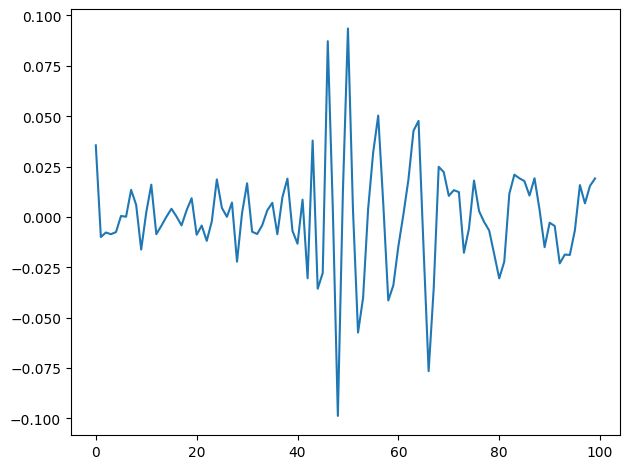

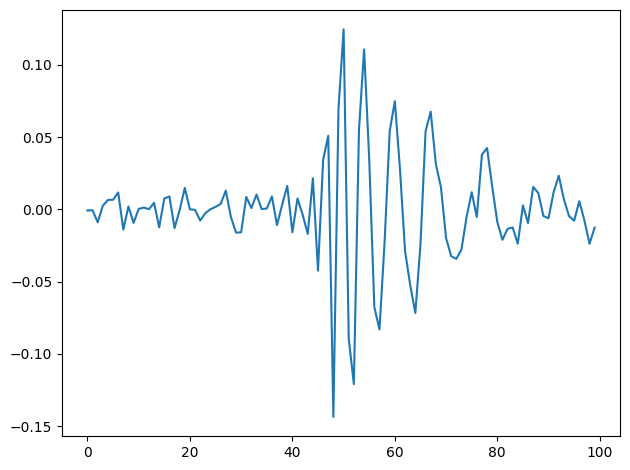

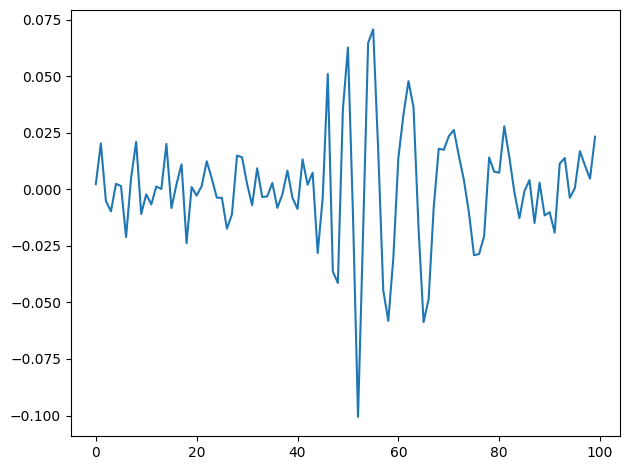

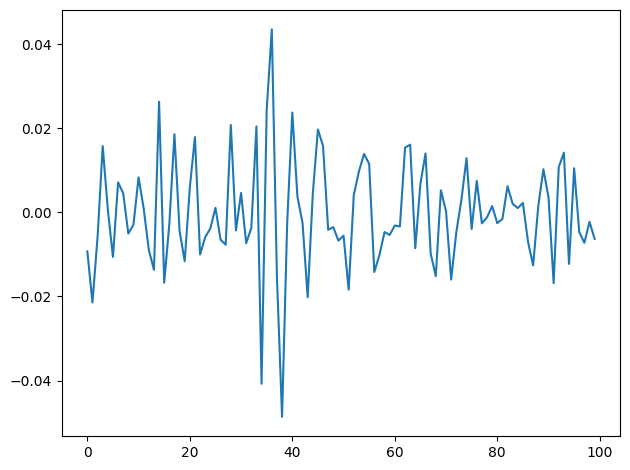

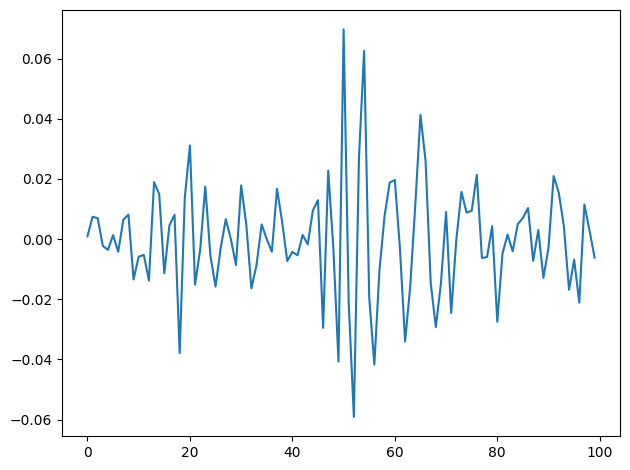

In [22]:
# plot a few signal events
for trace in x[smask][:5]:
  fig, ax = plt.subplots(1, 1)
  ax.plot(trace)
  fig.tight_layout()
  plt.show()

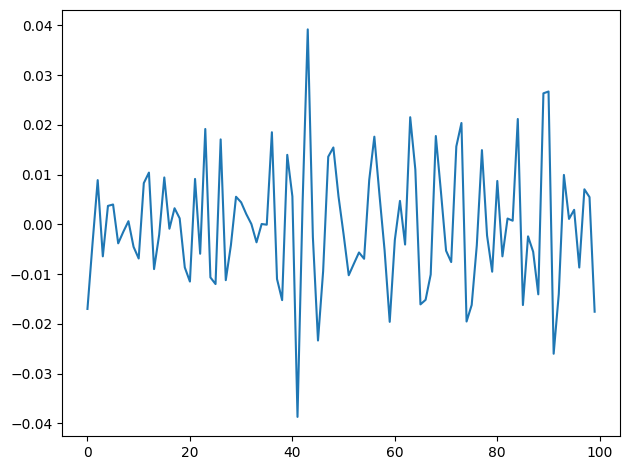

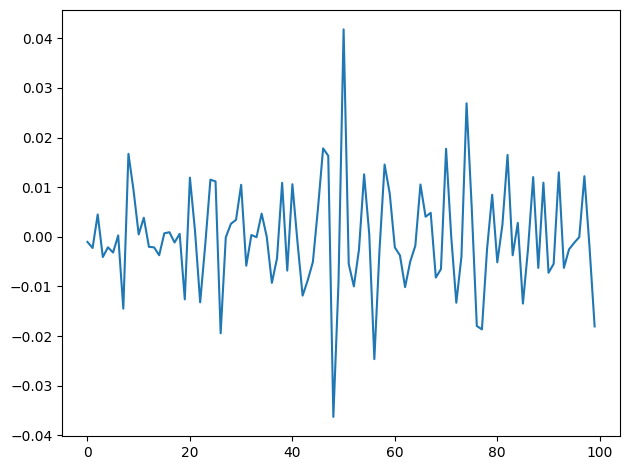

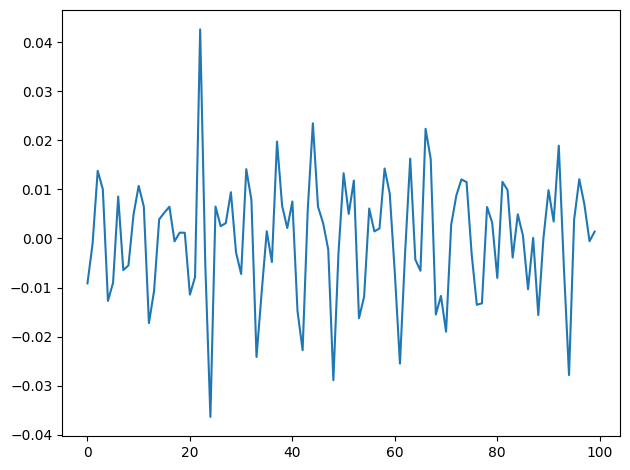

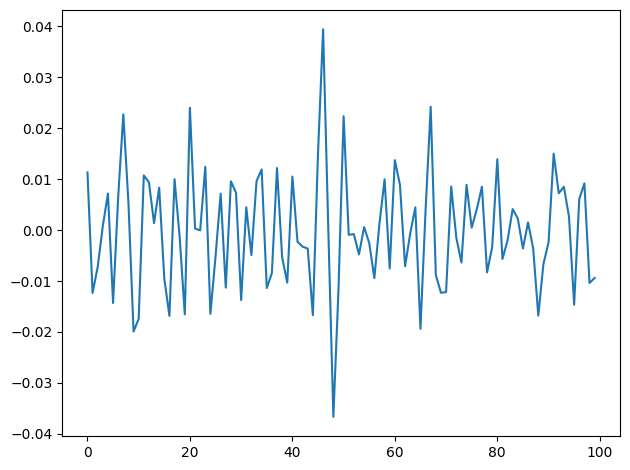

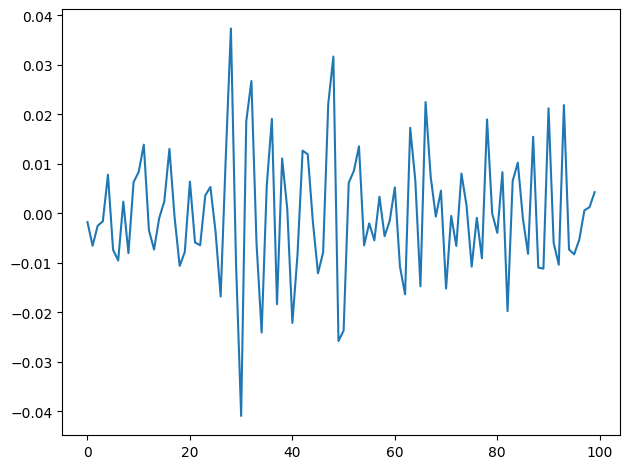

In [23]:
for trace in x[~smask][:5]:
  fig, ax = plt.subplots(1, 1)
  ax.plot(trace)
  fig.tight_layout()
  plt.show()

The signal data seems to have regions with high intensity, while the noise plots have high amplitudes aver the full x-axis. But that also might just be because of the random five picks for each category. In the end I wouldn't trust myself to differentiate between signal and noise.

In [24]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [25]:
model = Sequential(
    [
        keras.layers.Input(shape=x_scaled.shape[1:]),
        Dense(64, activation="swish"),
        Dense(32, activation="swish"),
        Dense(1, activation="sigmoid")
    ],
    name="simple_dense"
)
print(model.summary())

Model: "simple_dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         6,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,577 (33.50 KB)

 Trainable params: 8,577 (33.50 KB)

 Non-trainable params: 0 (0.00 B)

None


In [26]:
csv_logger = keras.callbacks.CSVLogger('training_history.csv', append=False)


In [27]:
model.compile(
    optimizer=optimizer,
    loss=keras.losses.BinaryCrossentropy(),
    metrics=[keras.metrics.BinaryAccuracy(name="accuracy")]
)

model.fit(x_scaled, y, 
          batch_size=32, 
          epochs=20, 
          validation_split=0.2,
          callbacks=[csv_logger, keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True)])

model.save("simple_dense.h5")

Epoch 1/20


2026-07-06 15:39:31.768629: I external/local_xla/xla/service/service.cc:163] XLA service 0x769d1400aab0 initialized for platform ROCM (this does not guarantee that XLA will be used). Devices:
2026-07-06 15:39:31.768642: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): AMD Radeon RX 6950 XT, AMDGPU ISA version: gfx1030
2026-07-06 15:39:31.799216: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-06 15:39:31.919933: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


   75/15000 ━━━━━━━━━━━━━━━━━━━━ 33s 2ms/step - accuracy: 0.6699 - loss: 0.6294 

I0000 00:00:1783352373.565551    3038 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


14996/15000 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9736 - loss: 0.0824

2026-07-06 15:40:05.990039: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.


15000/15000 ━━━━━━━━━━━━━━━━━━━━ 44s 3ms/step - accuracy: 0.9883 - loss: 0.0398 - val_accuracy: 0.9943 - val_loss: 0.0201
Epoch 2/20
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9950 - loss: 0.0189 - val_accuracy: 0.9952 - val_loss: 0.0173
Epoch 3/20
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.9959 - loss: 0.0156 - val_accuracy: 0.9962 - val_loss: 0.0151
Epoch 4/20
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 40s 3ms/step - accuracy: 0.9964 - loss: 0.0139 - val_accuracy: 0.9961 - val_loss: 0.0148
Epoch 5/20
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step - accuracy: 0.9967 - loss: 0.0129 - val_accuracy: 0.9964 - val_loss: 0.0140
Epoch 6/20
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.9969 - loss: 0.0116 - val_accuracy: 0.9965 - val_loss: 0.0140
Epoch 7/20
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 38s 3ms/step - accuracy: 0.9972 - loss: 0.0109 - val_accuracy: 0.9964 - val_loss: 0.0141
Epoch 8/20
15000/15000 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step - accuracy: 0.9974 - lo

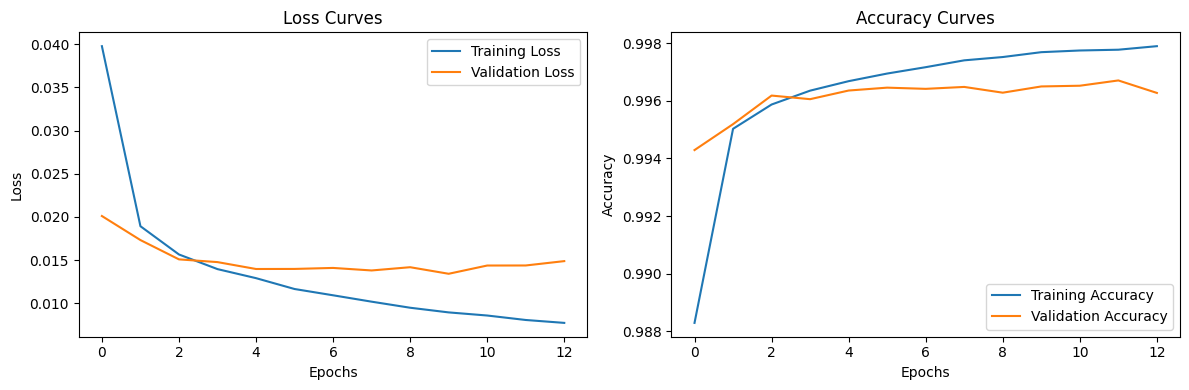

In [28]:
# plot loss and accuracy curves
df = pd.read_csv("training_history.csv")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(df['loss'], label='Training Loss')
plt.plot(df['val_loss'], label='Validation Loss')
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(df['accuracy'], label='Training Accuracy')
plt.plot(df['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

18750/18750 ━━━━━━━━━━━━━━━━━━━━ 22s 1ms/step


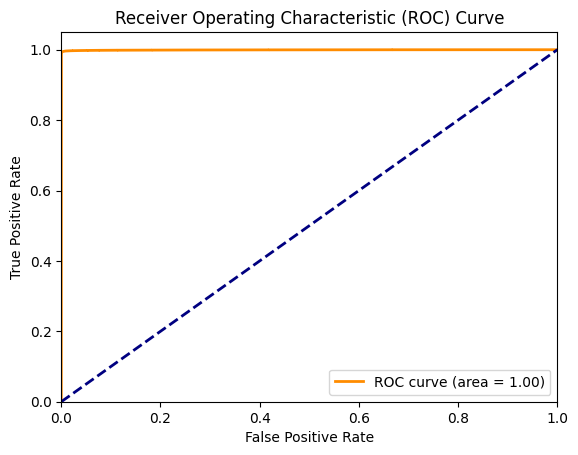

In [29]:
# plot ROC curve
y_pred = model.predict(x_scaled).ravel()
y_true = y

fpr, tpr, _ = roc_curve(y_true, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

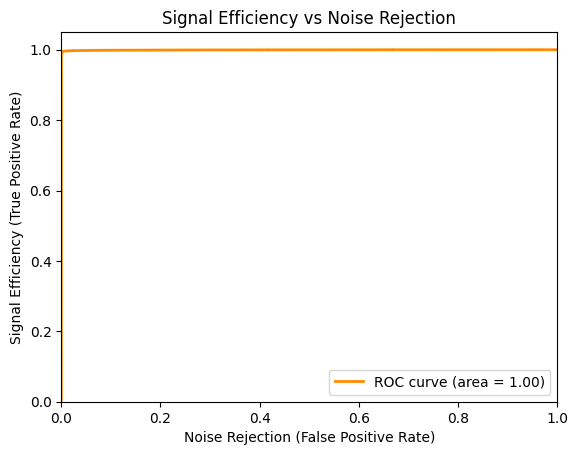

In [30]:
# plot signal efficiency vs noise rejection
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Noise Rejection (False Positive Rate)')
plt.ylabel('Signal Efficiency (True Positive Rate)')
plt.title('Signal Efficiency vs Noise Rejection')
plt.legend(loc="lower right")